In [ ]:
import os
N_cores = 1
os.environ["OMP_NUM_THREADS"] = str(N_cores)        # export OMP_NUM_THREADS=4
os.environ["OPENBLAS_NUM_THREADS"] = str(N_cores)   # export OPENBLAS_NUM_THREADS=4
os.environ["MKL_NUM_THREADS"] = str(N_cores)        # export MKL_NUM_THREADS=6
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_cores) # export VECLIB_MAXIMUM_THREADS=4
os.environ["NUMEXPR_NUM_THREADS"] = str(N_cores)    # export NUMEXPR_NUM_THREADS=6

import numpy as np
import matplotlib.pyplot as plt

import jclsquant as jcl
import sys

from ham_creation import create_hex_ham
from lat_creation import get_positions_graphene
from core import DOS_sparse, frequency_analysis, load_data
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
# Benchmarking
from time import time
from datetime import timedelta

# Graphics


In [3]:
# ------------------------------------------------------------------------------
#### PARAMETERS OF THE MODEL
## PHYSICAL
# Type of light               
modifier_id = 'linear'
# Hamiltonian type
type_ham = 'hbn'
# Parameters of the ham (only read if hbn)
ham_params = 0.5
# Energy in pulse                        
E = 1.1
# Temperature                       
Temp = 1e-9
# Chemical potential
mu = 0.01
# Intensity param     (no units)
gamma = 0.020

## SIMULATION
# Size of hamiltonian (2**N_pot)
N_pot = 17
N = 2**N_pot
# Amount of periods to be simulated
n_periods = 100
# Simulation steps per period
steps_per_T = 1000
# Amount of measures per period
meas_per_T = 16
N_measures = meas_per_T*n_periods
# Amount of random vectors used in calculation
N_random_vector = 1
# Momenta
M = int(np.sqrt(N))
#M = 362

## RESULT ANALYSIS
# Range of searching the maximim frequency (in period^-1 units)
range_search = 1


In [4]:
## CALCULATED PARAMS
# ------------------------------------------------------------------------------
####  Defining a hamiltonian (own)

N1 = N2 = int(np.sqrt(N))//2
S = get_positions_graphene(N1, N2)
if type_ham=='hbn':
    Ham = create_hex_ham(S, N1, N2, t=-2.7, M=ham_params, a_l=0.25, out_format='ELL')
else:
    Ham = create_hex_ham(S, N1, N2, t=-2.7, M=0.0, out_format='ELL')

dE = (Ham.bounds[1] - Ham.bounds[0])/2
# Parameters of the laser
w = E/jcl.hbar_fs 
T = 2*np.pi/w    
t_vec = np.linspace(0,n_periods*T , steps_per_T*n_periods)   
# Amount of half multiples of E where the occupation is obtained
hE_reps = 2
# Broadening in the energies
broad = dE*np.pi/M
t_vec_measures = np.linspace(0, n_periods*T, N_measures)

# Print of parameters to check results
print('PARAMETERS OF CALCULATION')
print(f'Type of hamiltonian is {type_ham}')
print(f'Hamiltonian parameter is {ham_params}')
print(f'Type of light is {modifier_id}')
print(f'# of atoms: {N}')
print(f'# of moments: {M}')
print(f'Energy: {E} eV')
print(f'Intensity param: {gamma}')
print(f'Temperature: {Temp} K')
print(f'Chem potential: {mu} eV')
print(f'# of Random Vectors: {N_random_vector}')
print(f'# of periods: {n_periods}')
print(f'steps/period: {steps_per_T}')
print(f'# measures/T: {meas_per_T}')


# Names of file and info on graphs
fig_title_info = f'$N={{{2**N_pot}}}$, $\\hbar\\omega={E}$ eV, T={Temp} K, $\\mu$={mu} eV, $\\Gamma$={gamma}, M={M}\n'
extra_text = f'Light: {modifier_id}\n$\\delta E={broad:.3f}$\n# Rand Vecs: {N_random_vector}\nMeasures/T={meas_per_T}\nSteps/T={steps_per_T}'

#fig_title_info=f'Light: {modifier_id},$N={{{2**N_pot}}}$, $\\hbar\\omega={E}$ eV, T={Temp} K, $\\mu$={mu} eV, $\\Gamma$={gamma}\n$M={M}$, $R={N_random_vector}$, Meas/T={meas_per_T}, $St/T={steps_per_T}$'

EF_list, n_E_list, dos_list, dosn_list = load_data(modifier_id, N_pot, E, Temp, mu, gamma, 
                        M, N_random_vector, n_periods, meas_per_T, steps_per_T, type_ham, ham_params, R=None)
            
# Remaking the graphs of oscillations in time
hE_list = [hE*E/2 for hE in range(-hE_reps, hE_reps+1)]


PARAMETERS OF CALCULATION
Type of hamiltonian is hbn
Hamiltonian parameter is 0.5
Type of light is linear
# of atoms: 131072
# of moments: 362
Energy: 1.1 eV
Intensity param: 0.02
Temperature: 1e-09 K
Chem potential: 0.01 eV
# of Random Vectors: 1
# of periods: 100
steps/period: 1000
# measures/T: 16
1/1 calculations finished! Loading results...


Text(-2.2, 0.2, 'Light: linear\n$\\delta E=0.078$\n# Rand Vecs: 1\nMeasures/T=16\nSteps/T=1000')

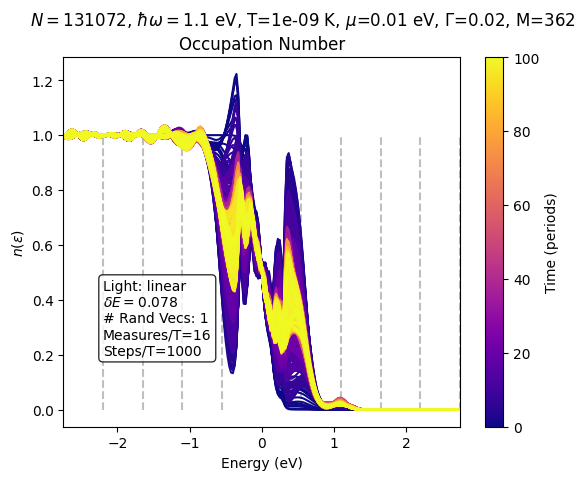

In [5]:
# Energy window and lines
cmap = plt.cm.plasma 
norm = Normalize(vmin=t_vec.min()/T, vmax=t_vec.max()/T)
min_e, max_e = -2.5*E, 2.5*E
hw_lines_step = 0.5*E
hw_hlines = [i for i in [hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]
hw_hlines += [i for i in [-hw_lines_step*i for i in range(1, int(max_e/hw_lines_step+1))]]
# ------------------------------------------------------------------------------
# Occupation (E)
# Text box
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
fig, ax = plt.subplots()
for i in range(N_measures):
    ax.plot(EF_list[i,:], n_E_list[i,:], color=cmap(norm(t_vec_measures[i]/T)), label=f't={round(t_vec_measures[i]/T, 3)}T')
#ax.legend()
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('$n(\\varepsilon)$')
ax.set_xlim(min_e, max_e)
ax.vlines(hw_hlines, 0, 1, color='grey', ls='--', alpha=0.5, zorder=1)
fig.suptitle(fig_title_info)
ax.set_title('Occupation Number')
ax.text(min_e + 0.5*E, 0.2, extra_text, bbox=props)


Text(0.5, 1.0, 'Density of States')

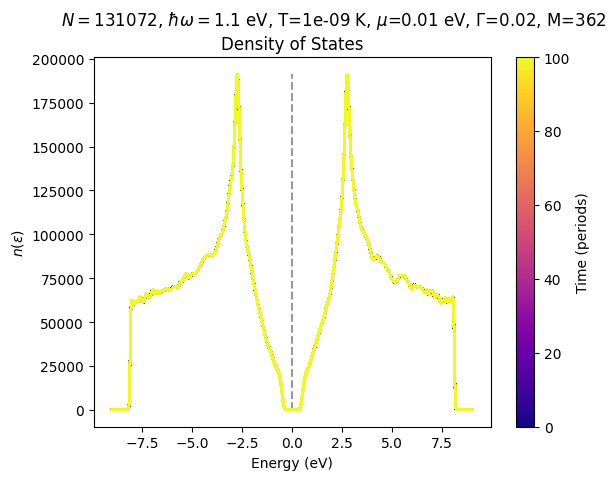

In [6]:
# ------------------------------------------------------------------------------
# DOS (Energy)
fig, ax = plt.subplots()
for i in range(N_measures):
    ax.plot(EF_list[i,:], dos_list[i,:], color=cmap(norm(t_vec_measures[i])), label=f't={round(t_vec_measures[i]/T, 3)}T')
#ax.legend()
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('$n(\\varepsilon)$')
#ax.vlines(hw_hlines, 0, np.max(dos_list), color='grey', ls='--', alpha=0.5, zorder=1)
ax.vlines([0], 0, np.max(dos_list), color='grey', ls='--', alpha=0.8, zorder=1)
fig.suptitle(fig_title_info)
ax.set_title('Density of States')

Text(0.5, 1.0, 'Density of States')

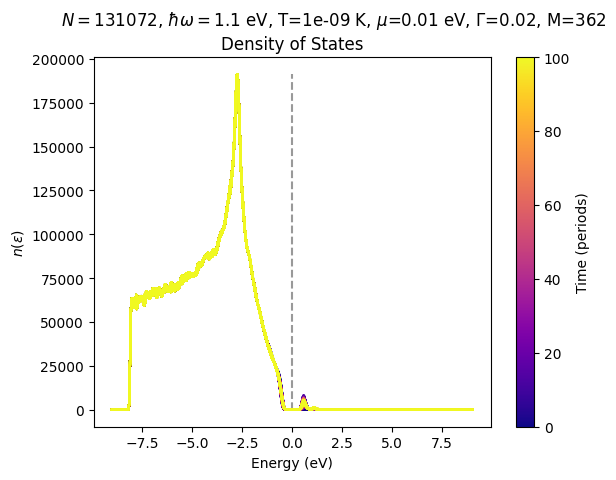

In [7]:
# ------------------------------------------------------------------------------
# DOS*Occ (Energy)
fig, ax = plt.subplots()
for i in range(N_measures):
    ax.plot(EF_list[i,:], dosn_list[i,:], color=cmap(norm(t_vec_measures[i])), label=f't={round(t_vec_measures[i]/T, 3)}T')
#ax.legend()
cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, orientation='vertical', label='Time (periods)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('$n(\\varepsilon)$')
#ax.vlines(hw_hlines, 0, np.max(dos_list), color='grey', ls='--', alpha=0.5, zorder=1)
ax.vlines([0], 0, np.max(dos_list), color='grey', ls='--', alpha=0.8, zorder=1)
fig.suptitle(fig_title_info)
ax.set_title('Density of States')


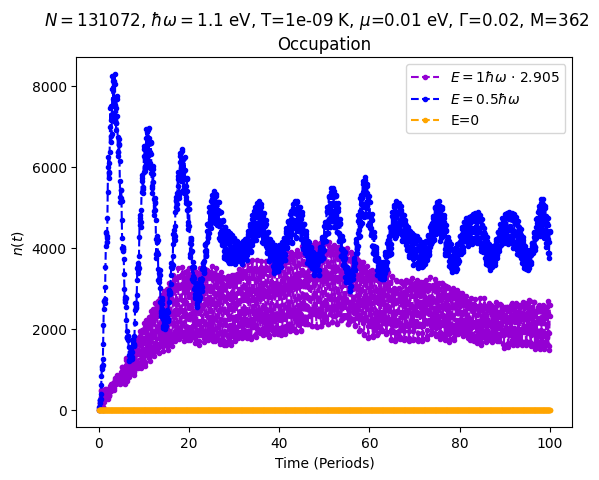

In [8]:
# ------------------------------------------------------------------------------
# OCCUPATION (Time)
color_list = ['olivedrab', 'red', 'orange', 'blue', 'darkviolet']

occ_drop_list, fourier_occ, freq, char_freq, max_freq_ind = frequency_analysis(EF_list, dosn_list, hE_list, t_vec_measures, T, range_search)
fig, ax = plt.subplots()
reescale = np.max(occ_drop_list[3]) / np.max(occ_drop_list[4]) / 2
ax.plot(np.array(t_vec_measures)/T, occ_drop_list[4]*reescale, c='darkviolet', 
        marker='.', ls='--', label=f"$E=1\\hbar\\omega$ $\\cdot$ {reescale:.3f}")
ax.plot(np.array(t_vec_measures)/T, occ_drop_list[3], c='blue', 
        marker='.', ls='--', label=f"$E=0.5\\hbar\\omega$")
ax.plot(np.array(t_vec_measures)/T, occ_drop_list[2], c='orange', 
        marker='.', ls='--', label=f"E=0")
ax.set_xlabel('Time (Periods)')
ax.set_ylabel('$n(t)$')
ax.set_title(fr'Occupation')
fig.suptitle(fig_title_info)
ax.legend()


Text(0.5, 0.98, '$N={131072}$, $\\hbar\\omega=1.1$ eV, T=1e-09 K, $\\mu$=0.01 eV, $\\Gamma$=0.02, M=362\n')

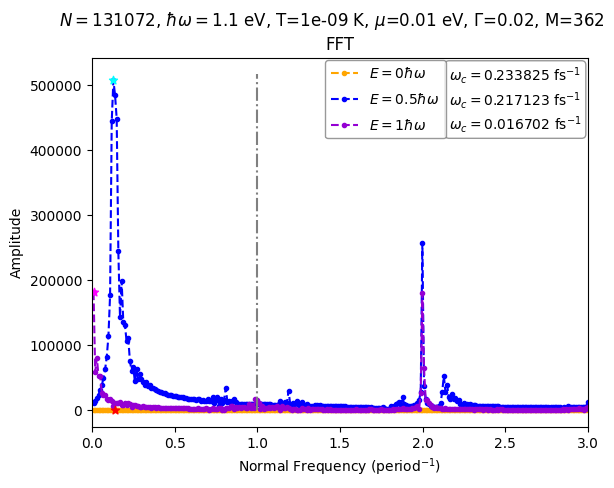

In [9]:
# ------------------------------------------------------------------------------
# FREQUENCY ANALYSIS OF THE RESULTS
# General figure
max_freq = min(3, freq[-1]*T/(2*np.pi))
props = dict(boxstyle='round', facecolor='white', edgecolor='grey', alpha=0.8)

fig, ax = plt.subplots()
ax.plot(freq*T/(2*np.pi), fourier_occ[2], c='orange', marker='.', ls='--', 
        label=f'$E = 0\\hbar\\omega$')
ax.plot(freq*T/(2*np.pi), fourier_occ[3], c='blue', marker='.', ls='--', 
        label=f'$E = 0.5\\hbar\\omega$')
ax.plot(freq*T/(2*np.pi), fourier_occ[4], c='darkviolet', marker='.', ls='--', 
        label=f'$E = 1\\hbar\\omega$')
# Markers of max frequencies
ax.scatter(freq[max_freq_ind[2]]*T/(2*np.pi), fourier_occ[2, max_freq_ind[2]], color='red',
           marker='*', zorder=2)
ax.scatter(freq[max_freq_ind[3]]*T/(2*np.pi), fourier_occ[3, max_freq_ind[3]], color='cyan',
           marker='*', zorder=2)
ax.scatter(freq[max_freq_ind[4]]*T/(2*np.pi), fourier_occ[4, max_freq_ind[4]], color='magenta',
           marker='*', zorder=2)
ax.vlines([range_search], 0, np.max(fourier_occ), ls='-.', color='gray')
ax.set_xlim(0, max_freq)
wc_text = f'$\\omega_c = {char_freq[2]:.6f}$ fs$^{{-1}}$\n$\\omega_c = {char_freq[3]:.6f}$ fs$^{{-1}}$\n$\\omega_c = {char_freq[4]:.6f}$ fs$^{{-1}}$'
ax.text(0.72, 0.98, wc_text, transform=ax.transAxes,
        verticalalignment='top', bbox=props)
ax.legend(loc=(0.47, 0.7815), labelspacing=0.8, edgecolor='grey')
ax.set_xlabel('Normal Frequency (period$^{-1}$)')
ax.set_ylabel('Amplitude')
ax.set_title('FFT')
fig.suptitle(fig_title_info)
